<a href="https://www.kaggle.com/code/ionelaralucacrisan/eda-on-retail-data?scriptVersionId=294307289" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Perform exploratory data analysis on retail data with Python
- Coursera Project


# Introduction:

... for the moment the plan is to define the objectives, intention, - load the data, it is available - then discuss the analytical steps

... data source https://archive.ics.uci.edu/dataset/352/online+retail

Info on the variables:

* Variable Name	- Role	-  Type	  -         Description	
* InvoiceNo	  -  ID	 -     Categorical	-   a 6-digit integral number uniquely assigned to each transaction. 
* StockCode	 -   ID	   -   Categorical	 -  a 5-digit integral number uniquely assigned to each distinct product
* Description	-    Feature	-  Categorical	-   product name		
* Quantity	-    Feature	-  Integer	  -     the quantities of each product (item) per transaction
* InvoiceDate	-    Feature	-  Date	     -      the day and time when each transaction was generated
* UnitPrice	  -  Feature	-  Continuous	-   product price per unit	sterling
* CustomerID	-    Feature	-  Categorical	-   a 5-digit integral number uniquely assigned to each customer	
* Country	  -      Feature	-  Categorical	-   the name of the country where each customer resides


# Retreive the data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-retail-xlsx/Online Retail.xlsx


In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

# Get acquainted with the data 

In [3]:
OR = pd.read_excel('/kaggle/input/online-retail-xlsx/Online Retail.xlsx', index_col=0)

OR.head(7)

,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
InvoiceNo,,,,,,,
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom


In [4]:
# last 6 rows 

OR.tail(6)

,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
InvoiceNo,,,,,,,
581587,23256,CHILDRENS CUTLERY SPACEBOY,4,2011-12-09 12:50:00,4.15,12680.0,France
581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [5]:
#types of data 

OR.dtypes

StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [6]:
#check the number of entries 

OR.shape

(541909, 7)

In [7]:
#summary statistics 

OR[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


# Clean and Validate the Data 

In [8]:
# check for missing 

OR.isnull().sum()

# we have missing for description and customer ID, what do we do with the ones for description - try to drop the missing for description and keep the ones for ID 

StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# drop the missing 

#OR = OR.dropna()    # Dropping the missing values.
OR_clean = OR.dropna(subset=OR.columns.difference(['ClientID']))

OR.count()

OR_clean = OR.dropna(subset=['Description'])


In [10]:
cols_except_id = [col for col in OR.columns if col != 'ClientID']
OR_clean = OR.dropna(subset=cols_except_id)


In [11]:
OR_clean = OR.dropna(subset=OR.columns.difference(['ClientID'])) \
             .dropna(subset=['Description'])


In [12]:
# check for missing 

OR.isnull().sum()

# we have missing for description and customer ID, what do we do with the ones for description 

StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [13]:
#check for duplicates 

OR.duplicated().sum()


np.int64(5848)

In [14]:
# the duplicates, another way 

duplicate_rows_OR = OR[OR.duplicated()]
print("number of duplicate rows: ", duplicate_rows_OR.shape)


number of duplicate rows:  (5848, 7)


In [15]:
#drop the duplicates

OR = OR.drop_duplicates()
OR.head(5)

,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
InvoiceNo,,,,,,,
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [16]:
OR.duplicated().sum()

np.int64(0)

In [17]:
# check for outliers 


In [18]:
# detect range values for columns of the dataset 

OR[['Quantity', 'UnitPrice']].describe([x*0.1 for x in range(4)])

,Quantity,UnitPrice
count,536061.000000,536061.000000
mean,9.646148,4.631014
std,218.855105,97.285571
min,-80995.000000,-11062.060000
0%,-80995.000000,-11062.060000
10%,1.000000,0.630000
20%,1.000000,0.850000
30%,2.000000,1.250000
50%,3.000000,2.080000
max,80995.000000,38970.000000


<Axes: xlabel='Quantity'>

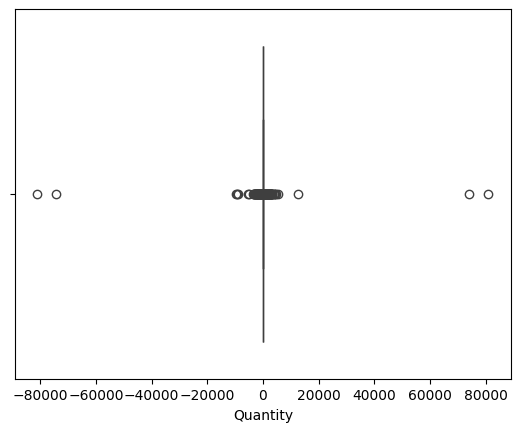

In [19]:
sns.boxplot(x=OR['Quantity'])

# think about how to deal with returned merchandise

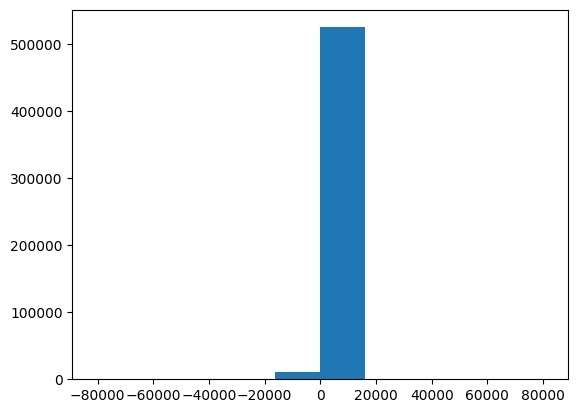

In [20]:
#histogram

plt.hist(OR[['Quantity']])
plt.show()

In [21]:
# deal with outliers 

# 

In [22]:
# unable to calculate correlation - sth to do with data types 

In [23]:
# list of products 

OR_product = OR['Description']

print(OR_product)

InvoiceNo
536365     WHITE HANGING HEART T-LIGHT HOLDER
536365                    WHITE METAL LANTERN
536365         CREAM CUPID HEARTS COAT HANGER
536365    KNITTED UNION FLAG HOT WATER BOTTLE
536365         RED WOOLLY HOTTIE WHITE HEART.
                         ...                 
581587            PACK OF 20 SPACEBOY NAPKINS
581587           CHILDREN'S APRON DOLLY GIRL 
581587          CHILDRENS CUTLERY DOLLY GIRL 
581587        CHILDRENS CUTLERY CIRCUS PARADE
581587          BAKING SET 9 PIECE RETROSPOT 
Name: Description, Length: 536061, dtype: object


... what are the times with the highest sales?

In [24]:
# new column with the revenue 

OR['value'] = OR.Quantity * OR.UnitPrice

OR.head()

,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,value
InvoiceNo,,,,,,,,
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [25]:
# calculate income for each day 

income_each_day = OR.groupby("InvoiceDate")['value'].sum()

print(income_each_day)

InvoiceDate
2010-12-01 08:26:00    139.12
2010-12-01 08:28:00     22.20
2010-12-01 08:34:00    348.78
2010-12-01 08:35:00     17.85
2010-12-01 08:45:00    855.86
                        ...  
2011-12-09 12:23:00    124.60
2011-12-09 12:25:00    140.64
2011-12-09 12:31:00    329.05
2011-12-09 12:49:00    339.20
2011-12-09 12:50:00    249.45
Name: value, Length: 23260, dtype: float64


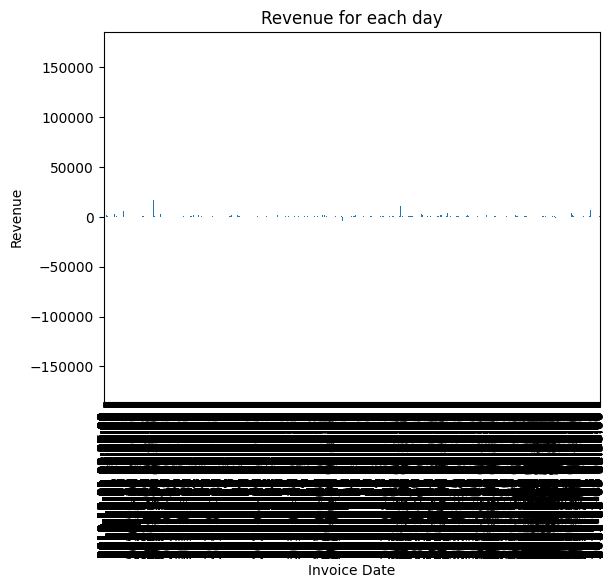

In [26]:
# Data visualisation - revenue for each day 

income_each_day.plot(kind='bar')
plt.title("Revenue for each day")
plt.xlabel("Invoice Date")
plt.ylabel("Revenue")
plt.show()



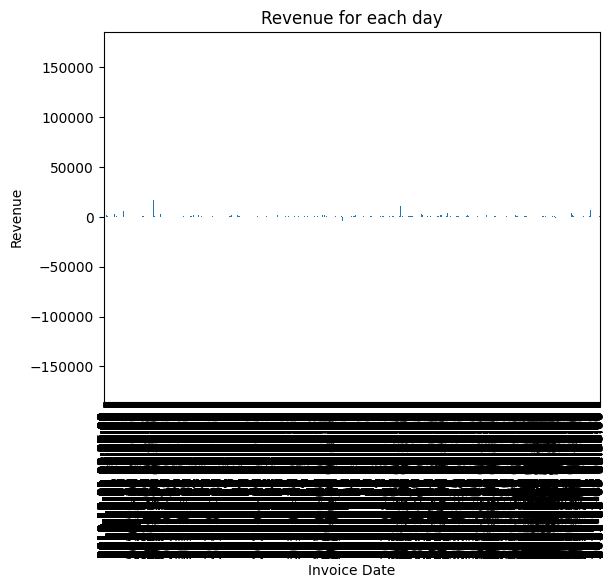

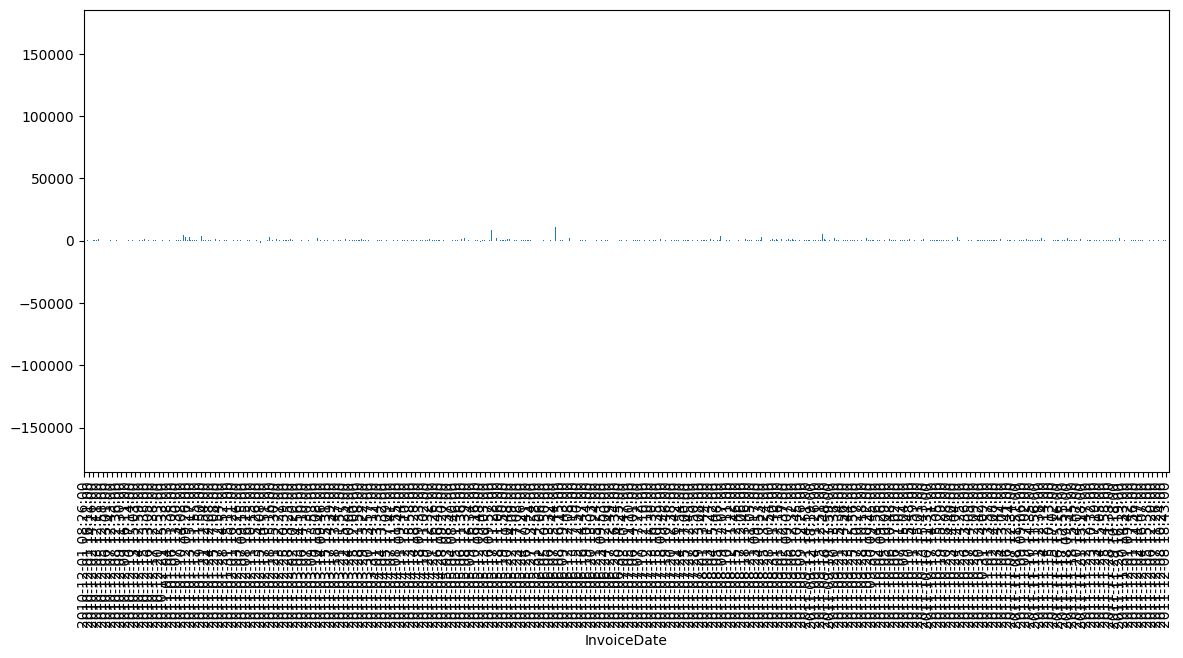

In [27]:

# Data visualisation - revenue for one in five day 

income_each_day.plot(kind='bar')
plt.title("Revenue for each day")
plt.xlabel("Invoice Date")
plt.ylabel("Revenue")
plt.show()

# trying to get a more readable graph

ax = income_each_day.plot(kind='bar', figsize=(14, 6))
ax.set_xticks(ax.get_xticks()[::100])  # one in 100 days 
plt.show()


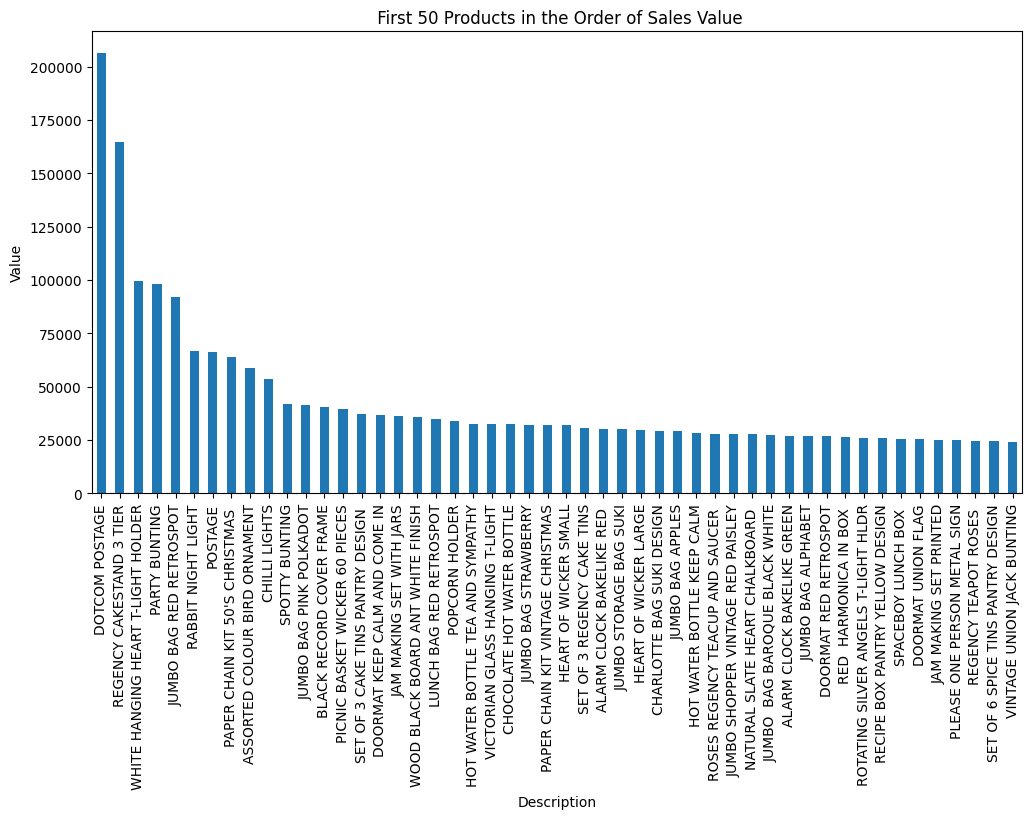

In [28]:
#first 50 products according to value

top_sales = OR.groupby('Description')['value'].sum()

top_50_sales = top_sales.sort_values(ascending=False).head(50)

top_50_sales.plot(kind='bar', figsize=(12,6))
plt.title(" First 50 Products in the Order of Sales Value")
plt.xlabel("Description")
plt.ylabel("Value")
plt.xticks(rotation=90)
plt.show()

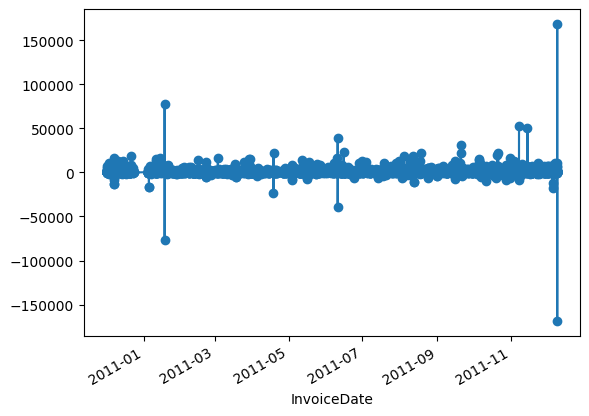

In [29]:
income_each_day.plot(
    x="Invoice Date",
    y="Revenue for Each Day",
    kind="line",
    marker="o"
)
plt.show()

# the highest sales are at the end of the year, that is normal for gifts

In [30]:
# calculate income for each product

income_each_object = OR.groupby("Description")['value'].sum()

print(income_each_object)

Description
20713                                0.00
 4 PURPLE FLOCK DINNER CANDLES     285.70
 50'S CHRISTMAS GIFT BAG LARGE    2341.13
 DOLLY GIRL BEAKER                2876.25
 I LOVE LONDON MINI BACKPACK      1624.02
                                   ...   
wrongly marked carton 22804          0.00
wrongly marked. 23343 in box         0.00
wrongly sold (22719) barcode         0.00
wrongly sold as sets                 0.00
wrongly sold sets                    0.00
Name: value, Length: 4223, dtype: float64


In [31]:
# calculate income for each day

income_each_day = OR.groupby("InvoiceDate")['value'].sum()

print(income_each_day)

InvoiceDate
2010-12-01 08:26:00    139.12
2010-12-01 08:28:00     22.20
2010-12-01 08:34:00    348.78
2010-12-01 08:35:00     17.85
2010-12-01 08:45:00    855.86
                        ...  
2011-12-09 12:23:00    124.60
2011-12-09 12:25:00    140.64
2011-12-09 12:31:00    329.05
2011-12-09 12:49:00    339.20
2011-12-09 12:50:00    249.45
Name: value, Length: 23260, dtype: float64


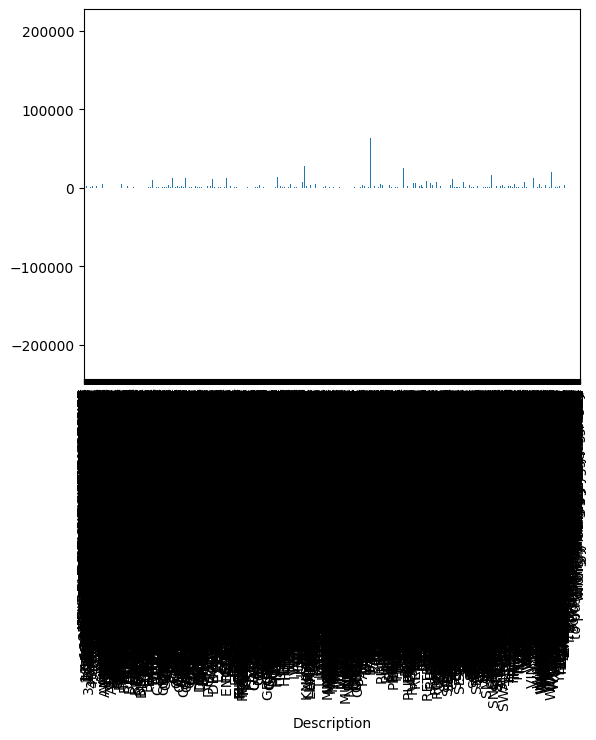

In [32]:
# bar chart - de corectat 

top_sales = OR.groupby('Description')['value'].sum()
top_sales.plot(kind='bar')
plt.show()

In [33]:
description_list = (
            OR["Description"]
            .value_counts()
            .loc[lambda x: x > 1]
            .index
            .tolist()
)

len(description_list)

# we have diffrerent 3698 products  in our database

3914

In [34]:
customer_country_list = (
            OR["Country"]
            .value_counts()
            .loc[lambda x: x > 1]
            .index
            .tolist()
)

print(customer_country_list)

['United Kingdom', 'Germany', 'France', 'EIRE', 'Spain', 'Netherlands', 'Belgium', 'Switzerland', 'Portugal', 'Australia', 'Norway', 'Italy', 'Channel Islands', 'Finland', 'Cyprus', 'Sweden', 'Unspecified', 'Austria', 'Denmark', 'Japan', 'Poland', 'Israel', 'USA', 'Hong Kong', 'Singapore', 'Iceland', 'Canada', 'Greece', 'Malta', 'United Arab Emirates', 'European Community', 'RSA', 'Lebanon', 'Lithuania', 'Brazil', 'Czech Republic', 'Bahrain', 'Saudi Arabia']
